Visualize the result of the image space target reaching experiment

In [1]:
import os
import itertools
import numpy as np
import pickle
import matplotlib.pyplot as plt

import path_settings

In [2]:
def print_loss(exp_name, n_trials, spacing, margin):
    identifiers_of_interest = [exp_name]

    ### Generate cast-net data
    data_alias = 'CN0'

    img_width = 640
    img_height = 480
    x_targets = np.arange(margin, img_width - margin, spacing)
    y_targets = np.arange(margin, img_height - margin, spacing)
    combinations = list(itertools.product(x_targets, y_targets))

    n_data = len(combinations)
    print('Number of cast-net data points: ', n_data)

    # print the loss
    for identifier in identifiers_of_interest:

        method_dir = os.path.join(path_settings.results_dir, identifier)
        
        data_dir_outer = os.path.join(method_dir, data_alias)

        for i in range(n_data):
            for j in range(n_trials):

                x_target = combinations[i][0]
                y_target = combinations[i][1]

                data_dir = os.path.join(data_dir_outer, str(x_target).zfill(4) + '_' + str(y_target).zfill(4) + '_' + str(j).zfill(2))
                loss_save_dir = os.path.join(data_dir, 'loss.pkl')
                with open(loss_save_dir, 'rb') as file:
                    data = pickle.load(file)
                loss = data[-1]
                
                print(f"({x_target}, {y_target}), loss: {loss}")
    

In [3]:
def plot_heatmap(exp_name, n_trials, spacing, margin, fig_title, min_value=0, max_value=16):
    identifiers_of_interest = [exp_name]
    img_width = 640
    img_height = 480

    x_targets = np.arange(margin, img_width - margin, spacing)
    y_targets = np.arange(margin, img_height - margin, spacing)

    x_indices = {x: i for i, x in enumerate(x_targets)}
    y_indices = {y: i for i, y in enumerate(y_targets)}

    loss_matrix = np.zeros((len(y_targets), len(x_targets)))
    
    combinations = list(itertools.product(x_targets, y_targets))
    n_data = len(combinations)
    n_trials = 1  # As defined in your code

    for identifier in identifiers_of_interest:
        method_dir = os.path.join(path_settings.results_dir, identifier)
        data_alias = 'CN0'  # As defined in your code
        data_dir_outer = os.path.join(method_dir, data_alias)

        for i in range(n_data):
            for j in range(n_trials):
                x_target = combinations[i][0]
                y_target = combinations[i][1]
                
                data_dir = os.path.join(
                    data_dir_outer,
                    f"{str(x_target).zfill(4)}_{str(y_target).zfill(4)}_{str(j).zfill(2)}"
                )
                loss_save_dir = os.path.join(data_dir, 'loss.pkl')
                with open(loss_save_dir, 'rb') as file:
                    data = pickle.load(file)
                loss = data[-1]

                # Map x_target and y_target to indices in the loss_matrix
                ix = x_indices[x_target]
                iy = y_indices[y_target]
                loss_matrix[iy, ix] = loss
                
                print(f"Processing ({x_target}, {y_target}), loss: {loss}")
                
    # Define the extent of the heatmap
    x_min = x_targets[0] - spacing / 2
    x_max = x_targets[-1] + spacing / 2
    y_min = y_targets[0] - spacing / 2
    y_max = y_targets[-1] + spacing / 2

    loss_matrix_flipped = np.flip(loss_matrix, axis=0)

    plt.figure(figsize=(8, 6), dpi=300)
    plt.imshow(
        loss_matrix_flipped,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        interpolation='nearest',
        aspect='equal',  
        cmap='viridis',
        vmin=min_value,
        vmax=max_value
    )
        
    plt.colorbar(label='Error (Pixels)')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(fig_title)
    plt.show()



Processing (30, 30), loss: 1.0846329910202348
Processing (30, 70), loss: 0.2941823398026651
Processing (30, 110), loss: 0.7791862071787061
Processing (30, 150), loss: 0.7998535395342344
Processing (30, 190), loss: 0.5593026891412287
Processing (30, 230), loss: 0.8299943232145099
Processing (30, 270), loss: 0.7827698196826122
Processing (30, 310), loss: 2.07606603615782
Processing (30, 350), loss: 1.925707834277266
Processing (30, 390), loss: 1.045049811263323
Processing (30, 430), loss: 0.8920781798059065
Processing (70, 30), loss: 0.9156287031756946
Processing (70, 70), loss: 1.2999329985994763
Processing (70, 110), loss: 2.3246532667081143
Processing (70, 150), loss: 0.08965334665210045
Processing (70, 190), loss: 0.4312609248039378
Processing (70, 230), loss: 0.3912055569529408
Processing (70, 270), loss: 0.5410344951622814
Processing (70, 310), loss: 2.090050898629731
Processing (70, 350), loss: 1.194318571387114
Processing (70, 390), loss: 1.3392676198983193
Processing (70, 430), 

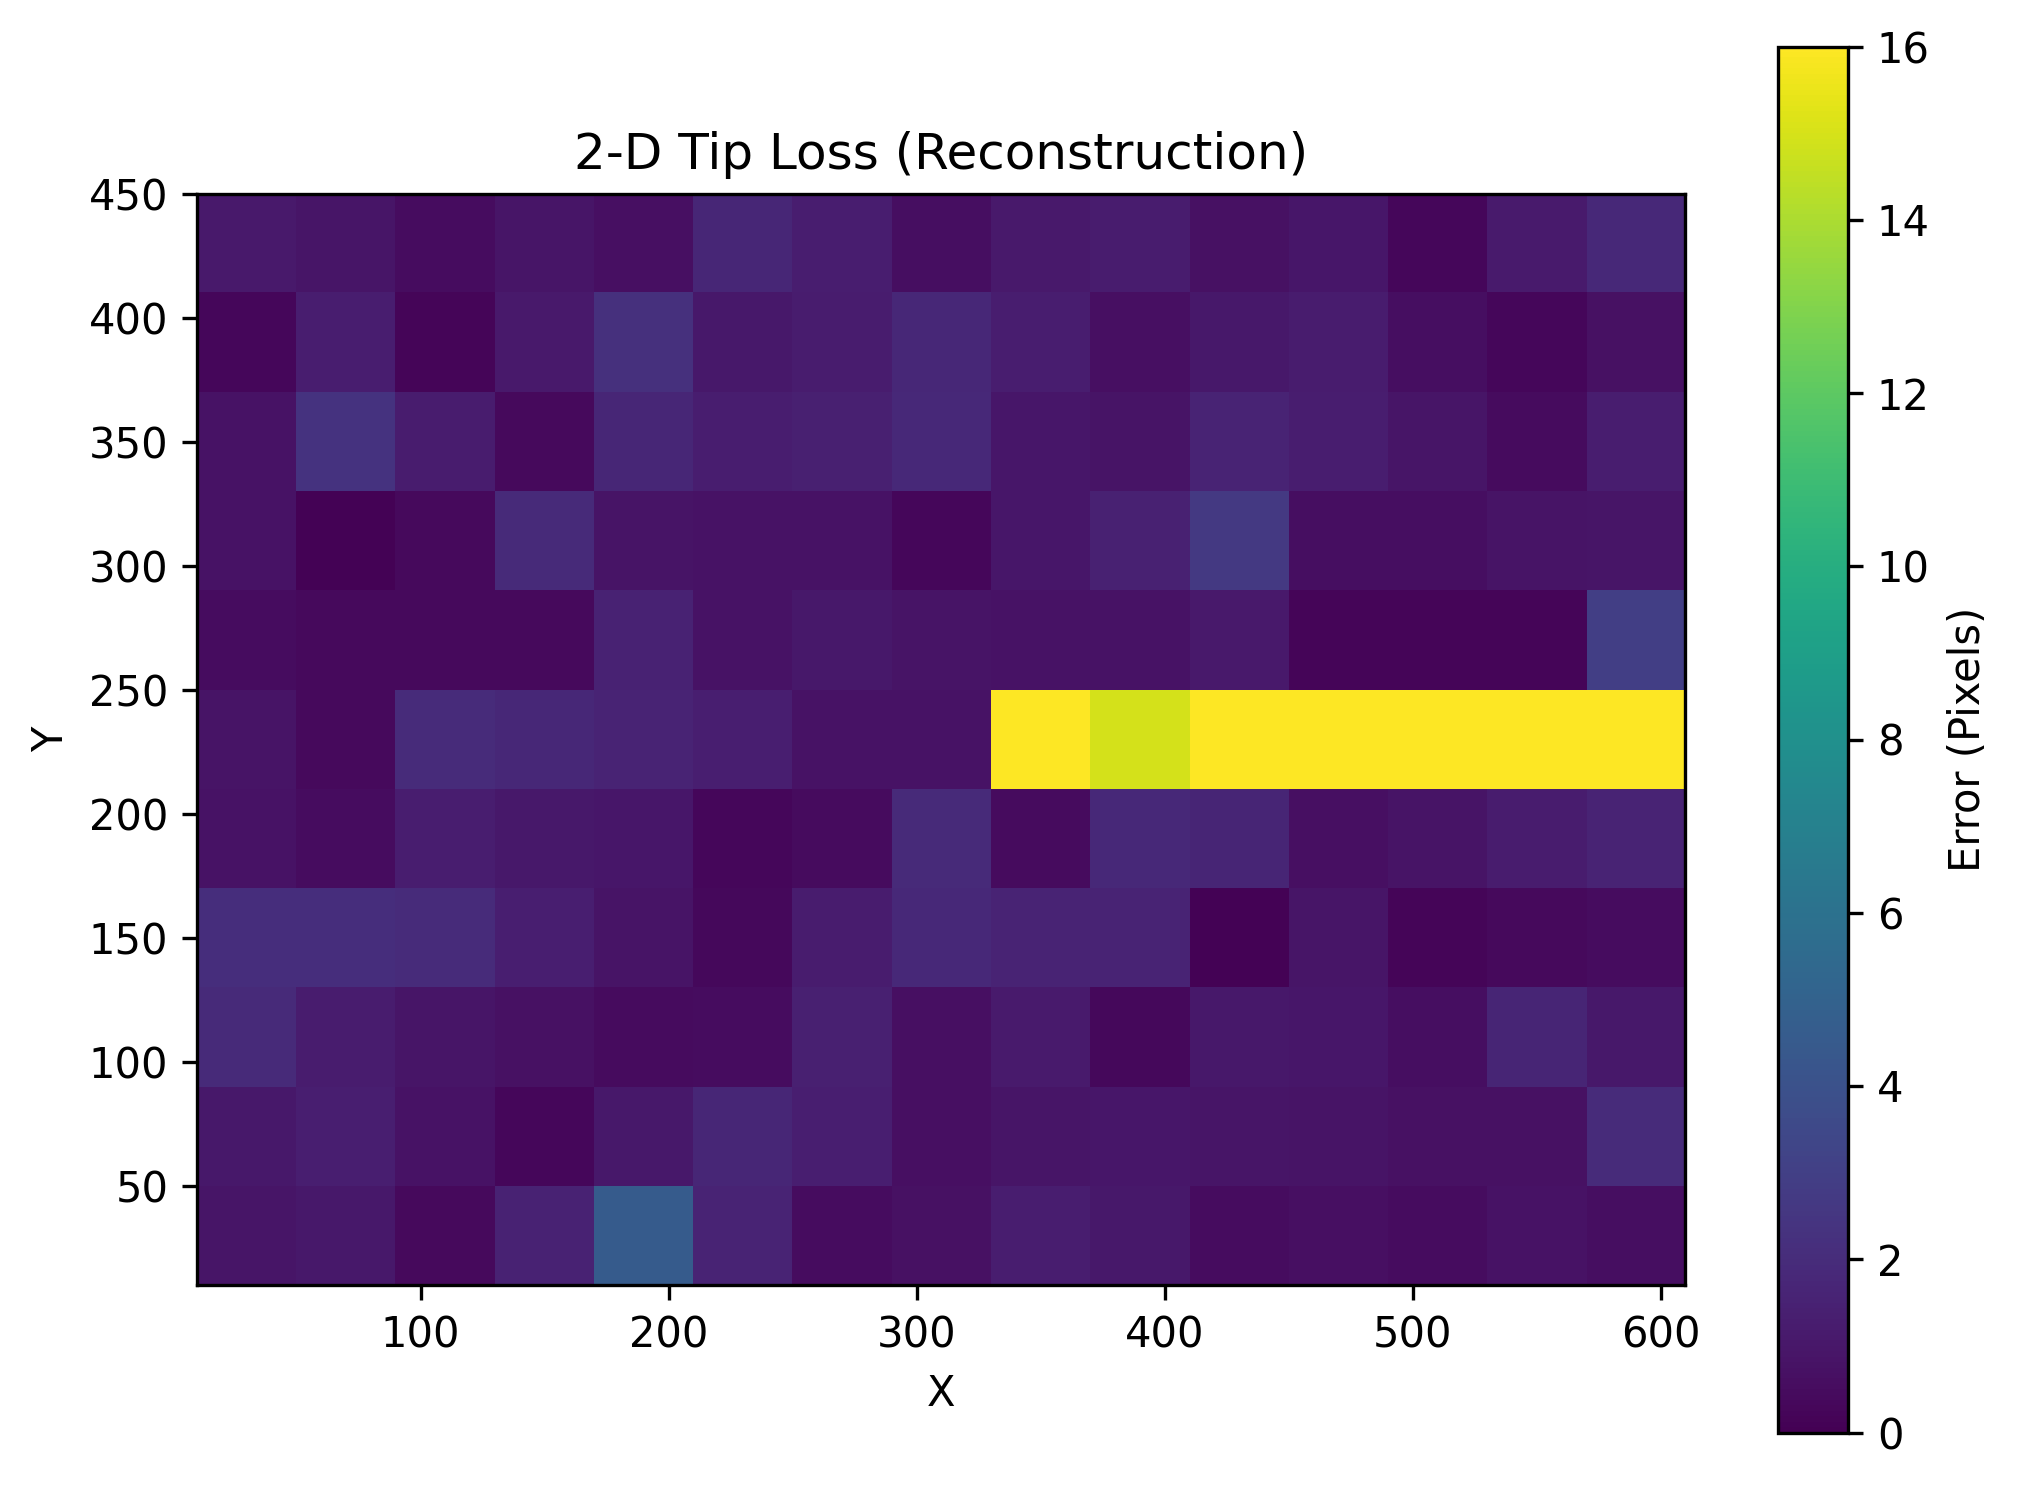

In [4]:
n_trials = 1
spacing = 40 
margin = 30

exp_name = "EXP005"
fig_title = "2-D Tip Loss (Reconstruction)"
plot_heatmap(exp_name, n_trials, spacing, margin, fig_title)

Processing (30, 30), loss: 0.00014975468893204858
Processing (30, 70), loss: 4.095061666088447e-05
Processing (30, 110), loss: 4.872090455831392e-05
Processing (30, 150), loss: 0.00015242988572768408
Processing (30, 190), loss: 1.295987726906284e-05
Processing (30, 230), loss: 1.4440605240981562e-05
Processing (30, 270), loss: 1.3328817280531813e-05
Processing (30, 310), loss: 9.061472951313031e-06
Processing (30, 350), loss: 4.432799321963996e-06
Processing (30, 390), loss: 9.918137163951753e-05
Processing (30, 430), loss: 2.524934446957052e-05
Processing (70, 30), loss: 8.384262710004419e-05
Processing (70, 70), loss: 1.1021439940151032e-05
Processing (70, 110), loss: 2.316354013981051e-05
Processing (70, 150), loss: 3.5955879063152617e-05
Processing (70, 190), loss: 0.0001447647633699983
Processing (70, 230), loss: 1.686380814132663e-05
Processing (70, 270), loss: 2.344155853331295e-05
Processing (70, 310), loss: 0.00011813184465851006
Processing (70, 350), loss: 1.6613270531144156e

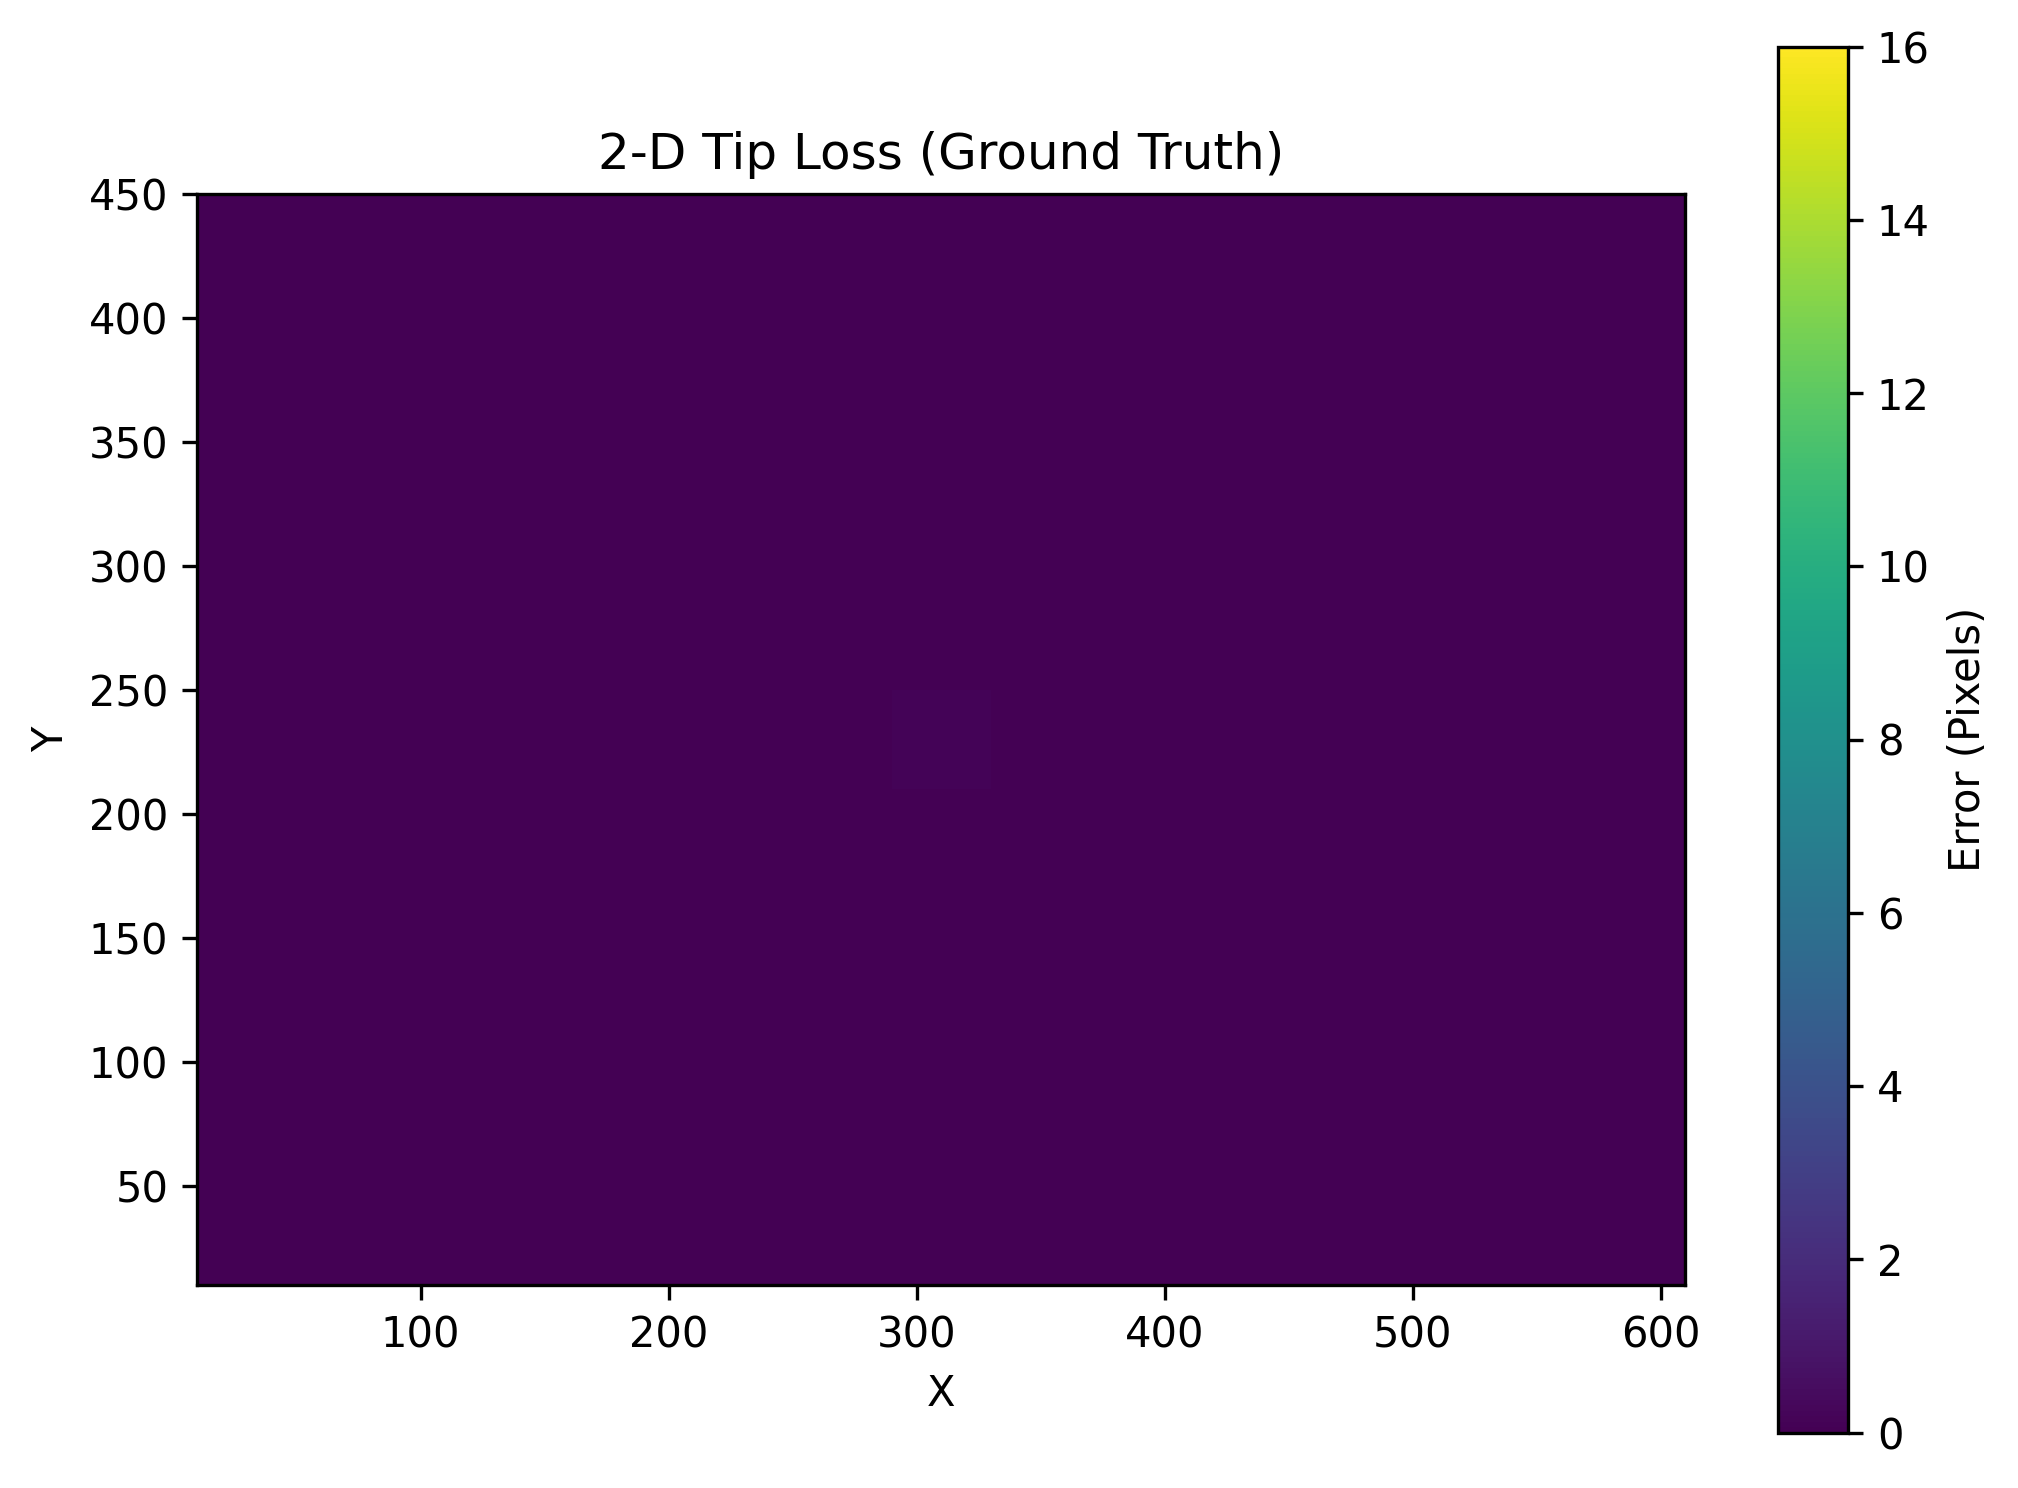

In [5]:
exp_name = "EXP006"
fig_title = "2-D Tip Loss (Ground Truth)" 
plot_heatmap(exp_name, n_trials, spacing, margin, fig_title, min_value=0, max_value=16)

Processing (30, 30), loss: 15.765960780217851
Processing (30, 70), loss: 5.144441351955956
Processing (30, 110), loss: 47.98866506441776
Processing (30, 150), loss: 25.61423092160243
Processing (30, 190), loss: 4.371146614778795
Processing (30, 230), loss: 28.447642152999666
Processing (30, 270), loss: 16.61135452793632
Processing (30, 310), loss: 12.865906845797902
Processing (30, 350), loss: 6.4073141193784195
Processing (30, 390), loss: 7.493112902117796
Processing (30, 430), loss: 6.548429530117211
Processing (70, 30), loss: 9.574237418901136
Processing (70, 70), loss: 7.6522901172756725
Processing (70, 110), loss: 17.463864521384878
Processing (70, 150), loss: 8.466432569828868
Processing (70, 190), loss: 7.949918770245867
Processing (70, 230), loss: 14.672096348384484
Processing (70, 270), loss: 14.917269020346536
Processing (70, 310), loss: 11.603545514534297
Processing (70, 350), loss: 8.78987546365599
Processing (70, 390), loss: 6.102998085438921
Processing (70, 430), loss: 14

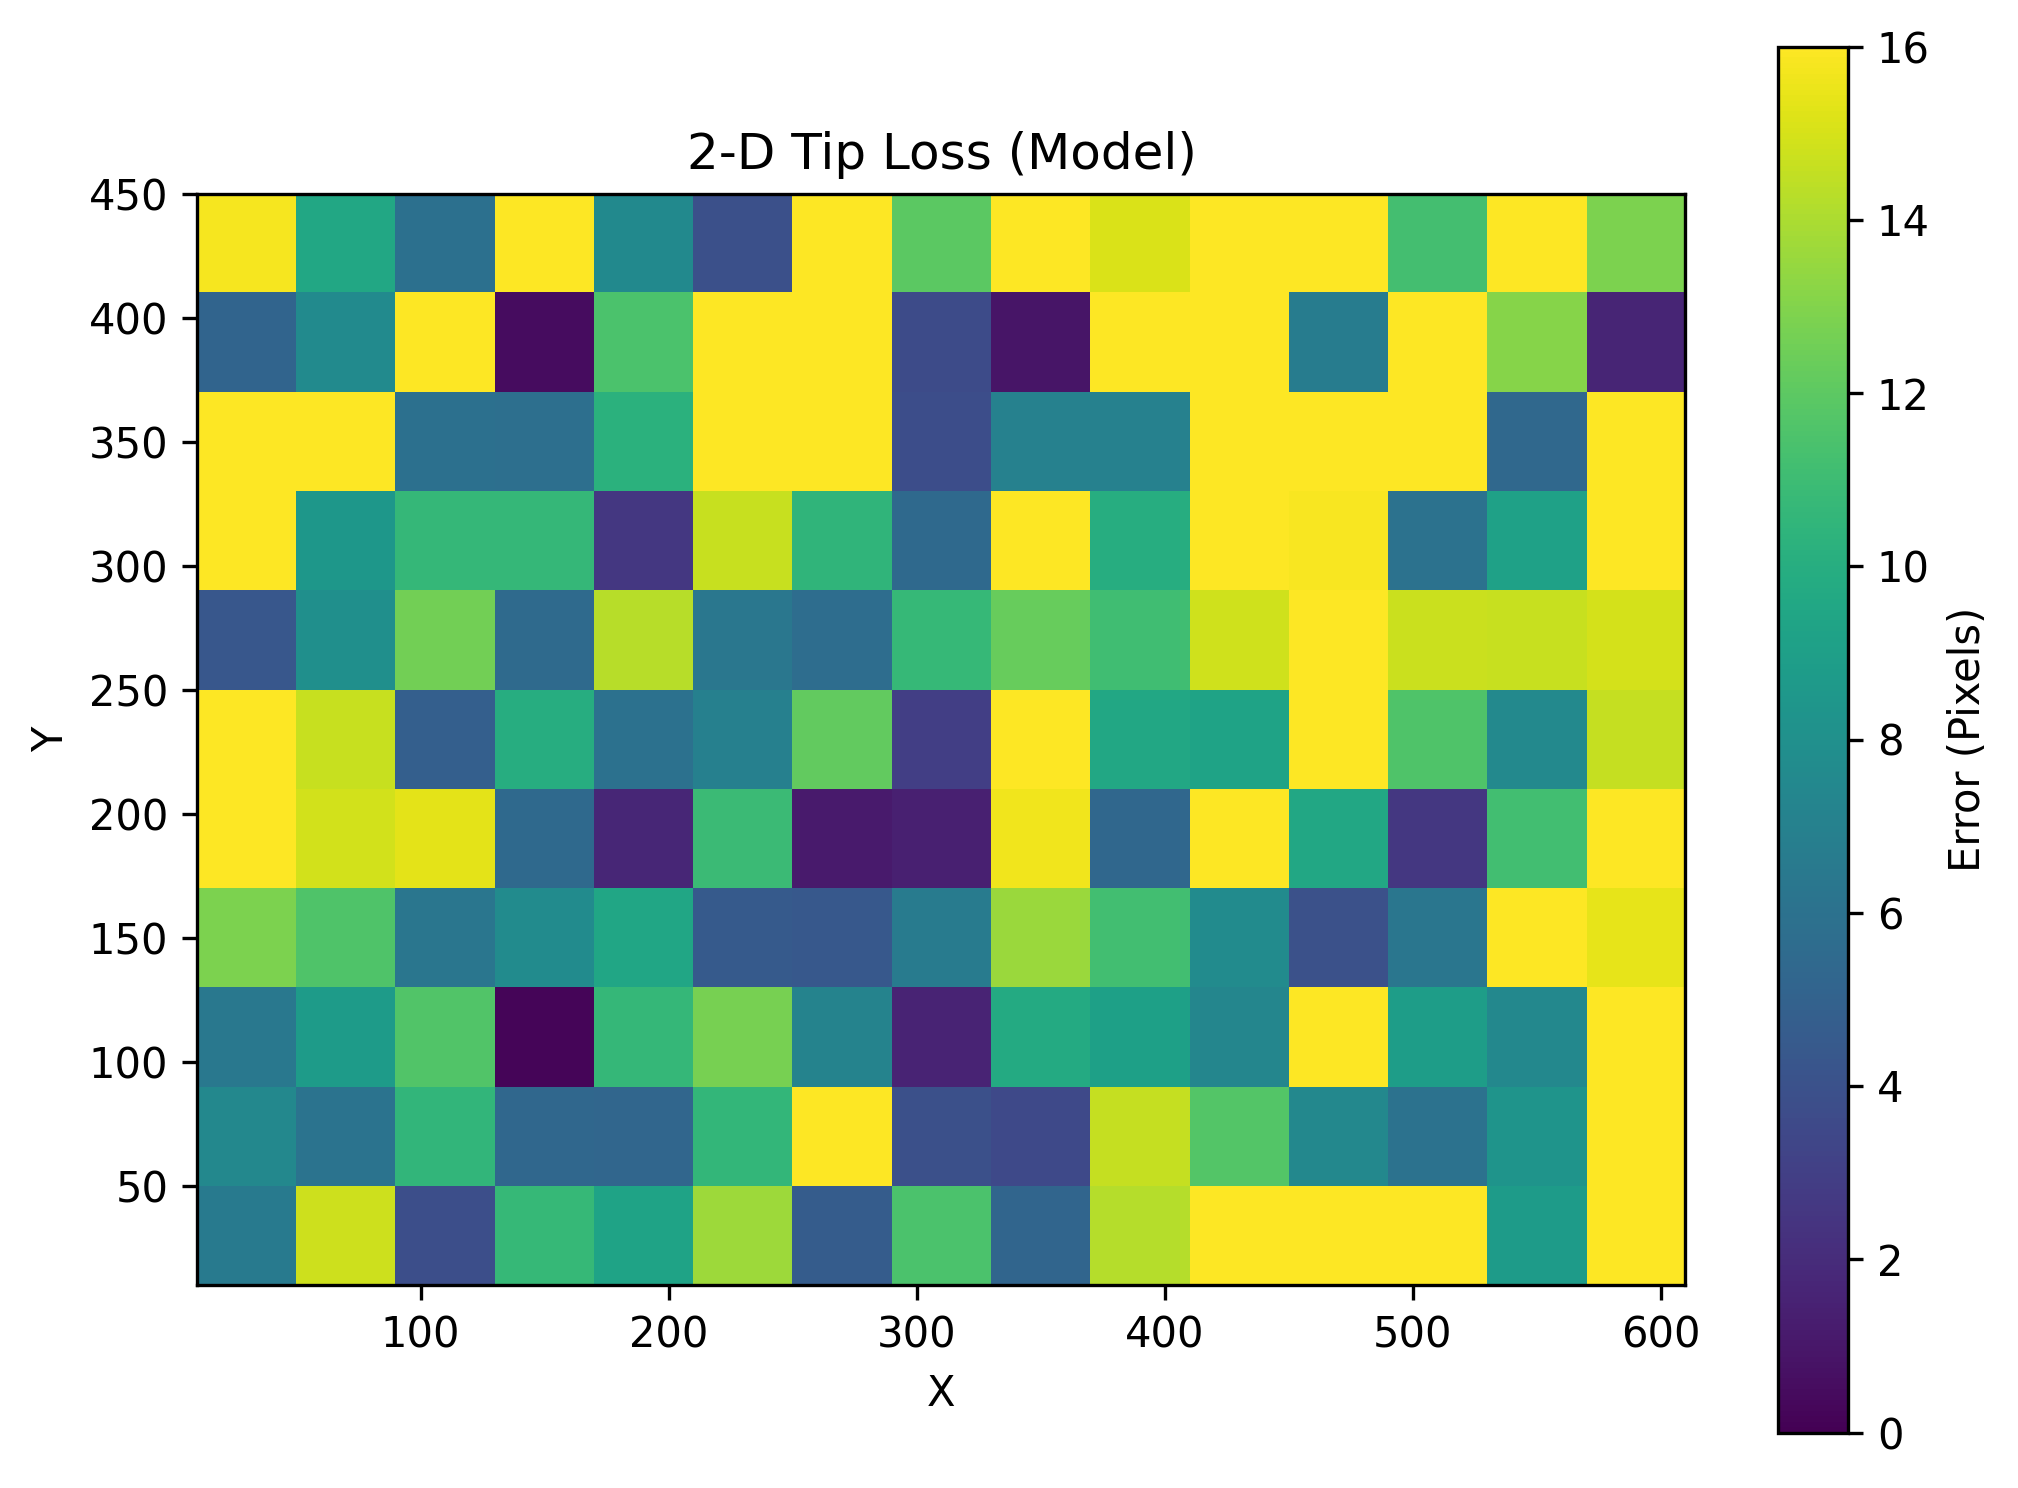

In [6]:
exp_name = "EXP013"
fig_title = "2-D Tip Loss (Model)" 
plot_heatmap(exp_name, n_trials, spacing, margin, fig_title, min_value=0, max_value=16)

In [7]:
# n_trials = 1
# spacing = 80 
# margin = 30

In [8]:
# exp_name = "EXP010"
# print_loss(exp_name, n_trials, spacing, margin)

In [9]:
# fig_title = "2-Dimensional Tip Loss (Ground Truth)"
# plot_heatmap(exp_name, n_trials, spacing, margin, fig_title)

In [10]:
# exp_name = "EXP009"
# print_loss(exp_name, n_trials, spacing, margin)

In [11]:
# fig_title = "2-Dimensional Tip Loss (Reconstruction)"
# plot_heatmap(exp_name, n_trials, spacing, margin, fig_title)